# X Education — Lead Analysis & Sales Intelligence
**Dataset:** X Education Lead Scoring (Kaggle)

X Education sells online courses to industry professionals.
Leads come from various sources (Google, referrals, direct, etc.)
but only ~30% end up converting to paying customers.

**Goal:** Understand *who* converts, *where* they come from,
and *what behaviours* signal a likely customer —
so the sales team can focus their efforts smarter.

**Output:** Actionable indicators for the sales team,
not a predictive model.

## 1. Imports

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Load Data

In [ ]:
# Update path if needed

df_raw = pd.read_csv('Leads Data Dictionary.csv')

print(f'Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Shape  : 9,240 rows × 37 columns


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.00,0,0.00,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.00,15.00,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.00,674,2.50,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.00,15.00,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.00,1532,2.00,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.00,20.00,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.00,305,1.00,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.00,17.00,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.00,1428,1.00,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.00,18.00,No,No,Modified


## 3. Dataset Overview

In [74]:
# Column names and dtypes
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   str    
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   str    
 3   Lead Source                                    9204 non-null   str    
 4   Do Not Email                                   9240 non-null   str    
 5   Do Not Call                                    9240 non-null   str    
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 non-null   

In [75]:
# Descriptive statistics — numeric columns
df_raw.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.00,9240.00,9103.00,9240.00,9103.00,5022.00,5022.00
mean,617188.44,0.39,3.45,487.70,2.36,14.31,16.34
std,23406.00,0.49,4.85,548.02,2.16,1.39,1.81
min,579533.00,0.00,0.00,0.00,0.00,7.00,11.00
25%,596484.50,0.00,1.00,12.00,1.00,14.00,15.00
50%,615479.00,0.00,3.00,248.00,2.00,14.00,16.00
75%,637387.25,1.00,5.00,936.00,3.00,15.00,18.00
max,660737.00,1.00,251.00,2272.00,55.00,18.00,20.00


In [76]:
# Target variable distribution
conv = df_raw['Converted'].value_counts()
conv_pct = df_raw['Converted'].value_counts(normalize=True) * 100

print('Converted  Count  Percentage')
print('─' * 35)
for val in conv.index:
    print(f'  {val}        {conv[val]:>5,}     {conv_pct[val]:.1f}%')

Converted  Count  Percentage
───────────────────────────────────
  0        5,679     61.5%
  1        3,561     38.5%


## 4. Missing Values Analysis

In [77]:
# Count and percentage of missing values per column
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing %'    : (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing)}')
display(missing)

Columns with missing values: 17


,Missing Count,Missing %
Lead Quality,4767,51.59
Asymmetrique Profile Score,4218,45.65
Asymmetrique Activity Index,4218,45.65
Asymmetrique Activity Score,4218,45.65
Asymmetrique Profile Index,4218,45.65
Tags,3353,36.29
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63


## 5. Basic Cleaning

In [78]:
df = df_raw.copy()

# ── 5.1  Column names: strip whitespace & replace spaces with underscores ──
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
print('Cleaned column names:')
print(df.columns.tolist())

Cleaned column names:
['prospect_id', 'lead_number', 'lead_origin', 'lead_source', 'do_not_email', 'do_not_call', 'converted', 'totalvisits', 'total_time_spent_on_website', 'page_views_per_visit', 'last_activity', 'country', 'specialization', 'how_did_you_hear_about_x_education', 'what_is_your_current_occupation', 'what_matters_most_to_you_in_choosing_a_course', 'search', 'magazine', 'newspaper_article', 'x_education_forums', 'newspaper', 'digital_advertisement', 'through_recommendations', 'receive_more_updates_about_our_courses', 'tags', 'lead_quality', 'update_me_on_supply_chain_content', 'get_updates_on_dm_content', 'lead_profile', 'city', 'asymmetrique_activity_index', 'asymmetrique_profile_index', 'asymmetrique_activity_score', 'asymmetrique_profile_score', 'i_agree_to_pay_the_amount_through_cheque', 'a_free_copy_of_mastering_the_interview', 'last_notable_activity']


In [79]:
# ── 5.2 Normalize lead source casing
if 'lead_source' in df.columns:
    df['lead_source'] = df['lead_source'].replace({'google': 'Google'})


In [80]:
# ── 5.3  Drop duplicate rows ──
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {n_before - len(df)}  →  Shape now: {df.shape}')

Duplicates removed: 0  →  Shape now: (9240, 37)


In [81]:
# ── 5.4  Fill missing values 

# Re-compute missing on df after cleaning
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

for col in missing_df.index:
    if pd.api.types.is_numeric_dtype(df[col]):
        # For high-missingness Asymmetrique columns, add an indicator flag first
        if missing_df.loc[col, 'Missing %'] > 20:
            flag_col = col + '_was_missing'
            df[flag_col] = df[col].isnull().astype(int)
            print(f'  Added flag column: {flag_col}')
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'  Numeric  "{col}"  → filled with median ({median_val:.2f})')
    else:
        df[col] = df[col].fillna('Missing')
        print(f'  Categorical "{col}" → filled with "Missing"')

print(f'\nRemaining NaNs in df: {df.isnull().sum().sum()}')


  Categorical "lead_quality" → filled with "Missing"
  Added flag column: asymmetrique_profile_score_was_missing
  Numeric  "asymmetrique_profile_score"  → filled with median (16.00)
  Categorical "asymmetrique_activity_index" → filled with "Missing"
  Added flag column: asymmetrique_activity_score_was_missing
  Numeric  "asymmetrique_activity_score"  → filled with median (14.00)
  Categorical "asymmetrique_profile_index" → filled with "Missing"
  Categorical "tags" → filled with "Missing"
  Categorical "what_matters_most_to_you_in_choosing_a_course" → filled with "Missing"
  Categorical "lead_profile" → filled with "Missing"
  Categorical "what_is_your_current_occupation" → filled with "Missing"
  Categorical "country" → filled with "Missing"
  Categorical "how_did_you_hear_about_x_education" → filled with "Missing"
  Categorical "specialization" → filled with "Missing"
  Categorical "city" → filled with "Missing"
  Numeric  "page_views_per_visit"  → filled with median (2.00)
  Numeri

In [82]:
# ── 5.5  Replace 'Select' placeholder strings with NaN ──
# Several categorical columns use 'Select' as a default unfilled value
df.replace('Select', np.nan, inplace=True)
print('Replaced "Select" with NaN')

Replaced "Select" with NaN


## 6. Cleaned Dataset Summary

In [83]:
print('=' * 45)
print('       CLEANED DATASET SUMMARY')
print('=' * 45)
print(f'Rows              : {df.shape[0]:,}')
print(f'Columns           : {df.shape[1]}')
print(f'Numeric columns   : {len(df.select_dtypes(include=np.number).columns)}')
print(f'Categorical cols  : {len(df.select_dtypes(include=["object", "string"]).columns)}')
print(f'Missing values    : {df.isnull().sum().sum()}')
print(f'Conversion rate   : {df["converted"].mean()*100:.1f}%')
print('=' * 45)
df.head()

       CLEANED DATASET SUMMARY
Rows              : 9,240
Columns           : 39
Numeric columns   : 9
Categorical cols  : 30
Missing values    : 13380
Conversion rate   : 38.5%


,prospect_id,lead_number,lead_origin,lead_source,do_not_email,do_not_call,converted,totalvisits,total_time_spent_on_website,page_views_per_visit,last_activity,country,specialization,how_did_you_hear_about_x_education,what_is_your_current_occupation,what_matters_most_to_you_in_choosing_a_course,search,magazine,newspaper_article,x_education_forums,newspaper,digital_advertisement,through_recommendations,receive_more_updates_about_our_courses,tags,lead_quality,update_me_on_supply_chain_content,get_updates_on_dm_content,lead_profile,city,asymmetrique_activity_index,asymmetrique_profile_index,asymmetrique_activity_score,asymmetrique_profile_score,i_agree_to_pay_the_amount_through_cheque,a_free_copy_of_mastering_the_interview,last_notable_activity,asymmetrique_profile_score_was_missing,asymmetrique_activity_score_was_missing
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.00,0,0.00,Page Visited on Website,Missing,NaN,NaN,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,NaN,NaN,02.Medium,02.Medium,15.00,15.00,No,No,Modified,0,0
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.00,674,2.50,Email Opened,India,NaN,NaN,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Missing,No,No,NaN,NaN,02.Medium,02.Medium,15.00,15.00,No,No,Email Opened,0,0
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.00,1532,2.00,Email Opened,India,Business Administration,NaN,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.00,20.00,No,Yes,Email Opened,0,0
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.00,305,1.00,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,NaN,Mumbai,02.Medium,01.High,13.00,17.00,No,No,Modified,0,0
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.00,1428,1.00,Converted to Lead,India,NaN,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,NaN,Mumbai,02.Medium,01.High,15.00,18.00,No,No,Modified,0,0


## 7. Data visualization for KPI metrics

### 🔹Conversion Basics: 


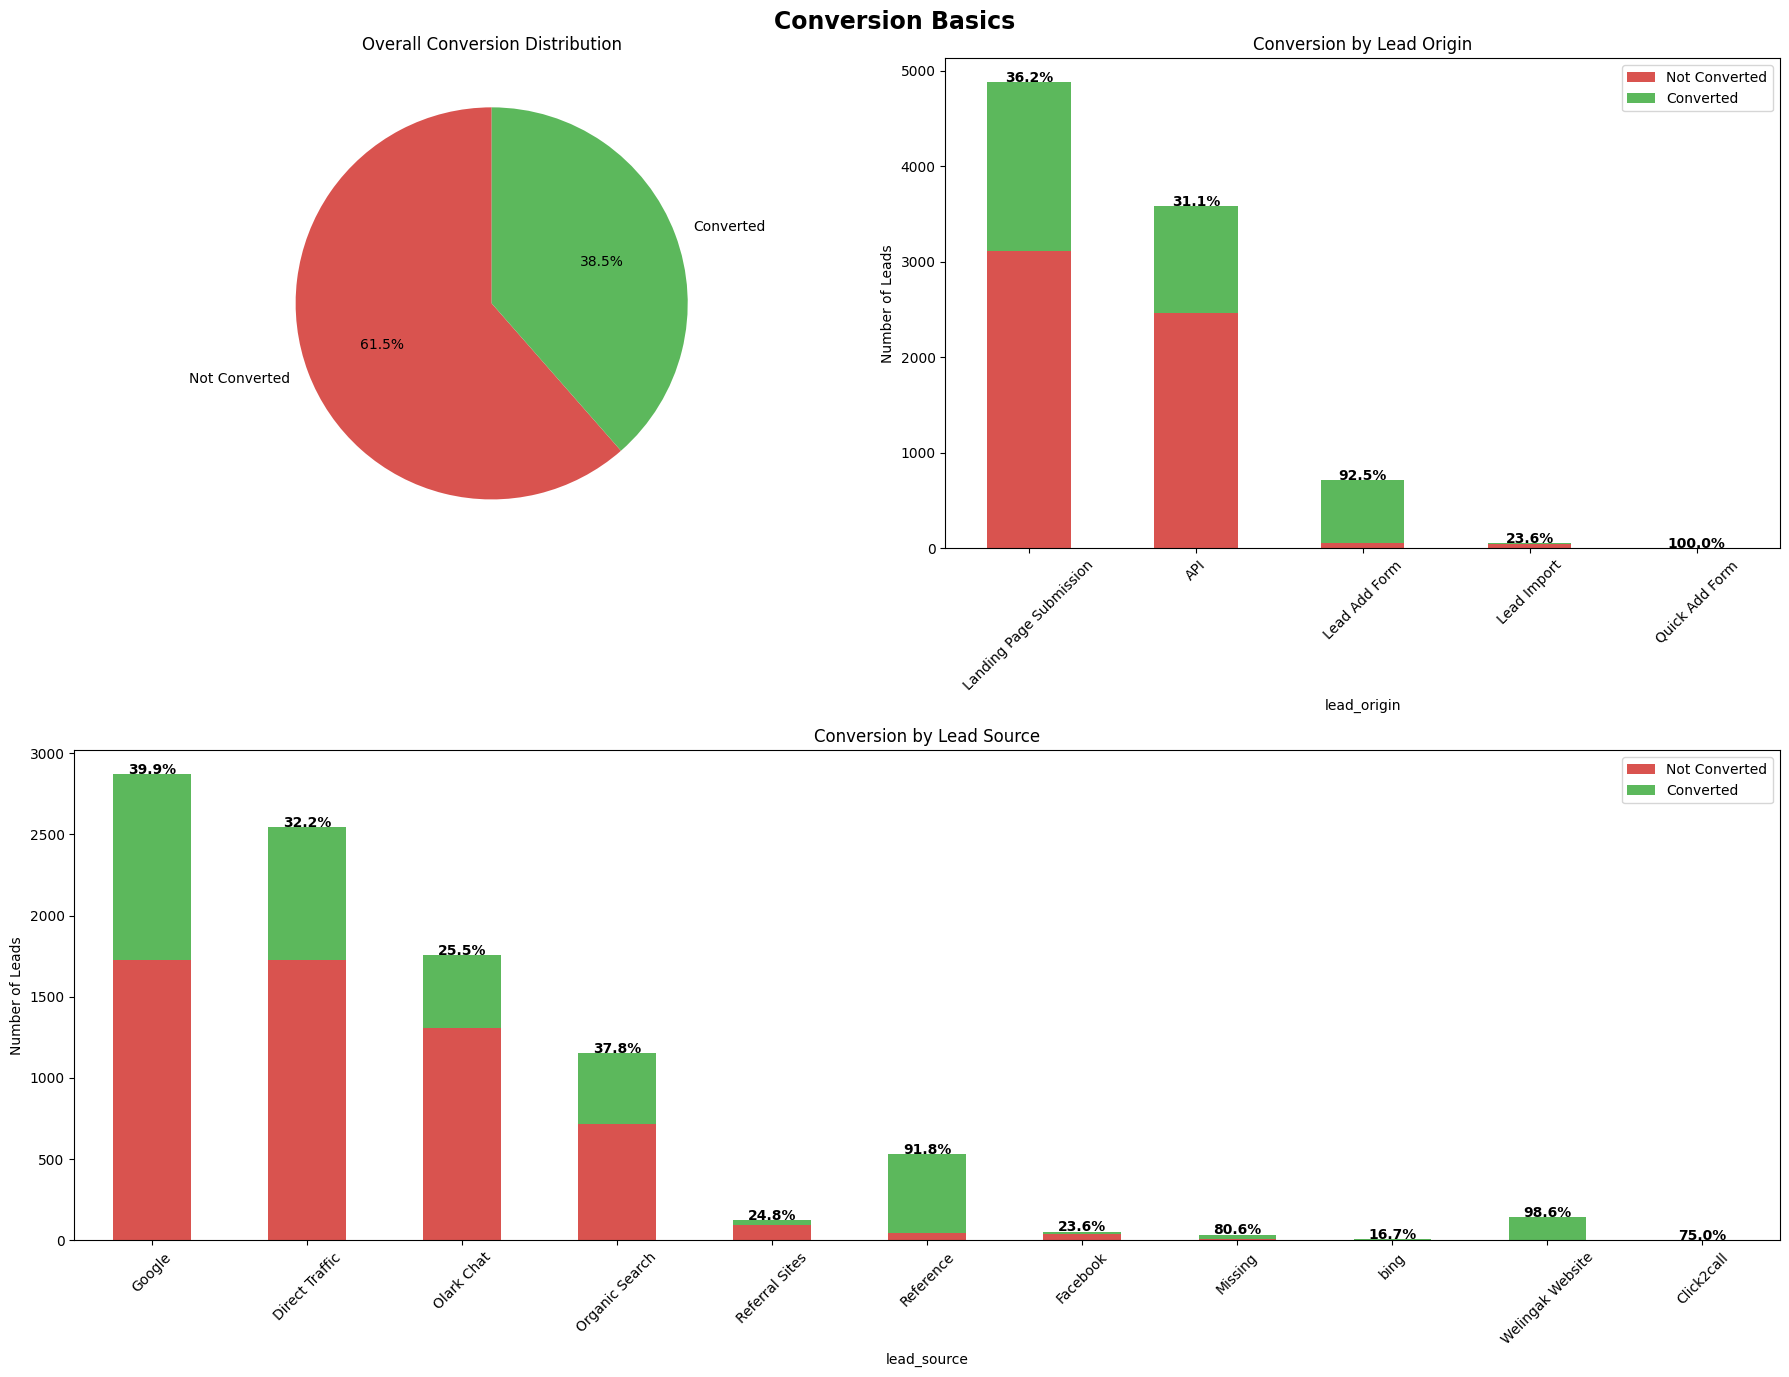

In [84]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2)

fig.suptitle('Conversion Basics', fontsize=17, fontweight='bold')

# --- 1. Overall conversion (PIE) ---
ax0 = fig.add_subplot(gs[0, 0])
conv_counts = df['converted'].value_counts()

ax0.pie(
    conv_counts.values,
    labels=['Not Converted', 'Converted'],
    autopct='%1.1f%%',
    colors=['#d9534f','#5cb85c'],
    startangle=90
)
ax0.set_title('Overall Conversion Distribution')

# --- 2. Lead Origin (STACKED BAR) ---
ax1 = fig.add_subplot(gs[0, 1])

origin_conv = pd.crosstab(df['lead_origin'], df['converted'])
origin_conv = origin_conv.sort_values(by=1, ascending=False)

origin_conv.plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=['#d9534f','#5cb85c']
)

ax1.set_title('Conversion by Lead Origin')
ax1.set_ylabel('Number of Leads')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(['Not Converted', 'Converted'])

# conversion rate
origin_rate = origin_conv[1] / origin_conv.sum(axis=1) * 100

# add labels above bars
for i, (total, rate) in enumerate(zip(origin_conv.sum(axis=1), origin_rate)):
    ax1.text(i, total + 1, f'{rate:.1f}%', ha='center', fontweight='bold')

# --- 3. Lead Source (STACKED BAR) ---
ax2 = fig.add_subplot(gs[1, :])

source_conv = pd.crosstab(df['lead_source'], df['converted'])
# filter: keep only sources with total leads >= 20
source_conv = source_conv[source_conv.sum(axis=1) > 2]
source_conv = source_conv.sort_values(by=0, ascending=False)

source_conv.plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    color=['#d9534f','#5cb85c']
)
# conversion rate
source_rate = source_conv[1] / source_conv.sum(axis=1) * 100

# add labels above bars
for i, (total, rate) in enumerate(zip(source_conv.sum(axis=1), source_rate)):
    ax2.text(i, total + 1, f'{rate:.1f}%', ha='center', fontweight='bold')
    

ax2.set_title('Conversion by Lead Source')
ax2.set_ylabel('Number of Leads')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(['Not Converted', 'Converted'])

plt.tight_layout()
plt.show()

## Insights – Lead Origin

**Lead Add Form (92.5%)** is the highest-converting entry method, reflecting strong pre-qualification by the sales team. **Landing Page Submission (36.2%)** is the most scalable inbound channel, while **Lead Import (23.6%)** is the weakest — likely due to stale or low-quality list data. API (31.1%) performance is heavily dependent on partner data quality.

> 🎯 **Call to Action:** Audit and reduce reliance on Lead Import. Prioritize Lead Add Form workflows and refine landing page funnels to push the current 36% conversion rate higher.

## Insights – Lead Source

**Trust-based and high-intent sources dominate:** Welingak Website (~98.6%) and Reference (~91.8%) convert exceptionally well. Google and Organic Search offer a strong volume-to-conversion balance. Low-intent channels — Facebook (23.6%), Referral Sites (24.8%), and Bing (16.7%) — convert significantly below average and drag down overall pipeline quality.

> 🎯 **Call to Action:** Invest more in referral programs and organic/Google search campaigns. Reevaluate Facebook and Bing ad spend, and redirect that budget toward Reference channel growth and high-intent inbound sources.

### 🔹 Geography — countries by Conversion Rate

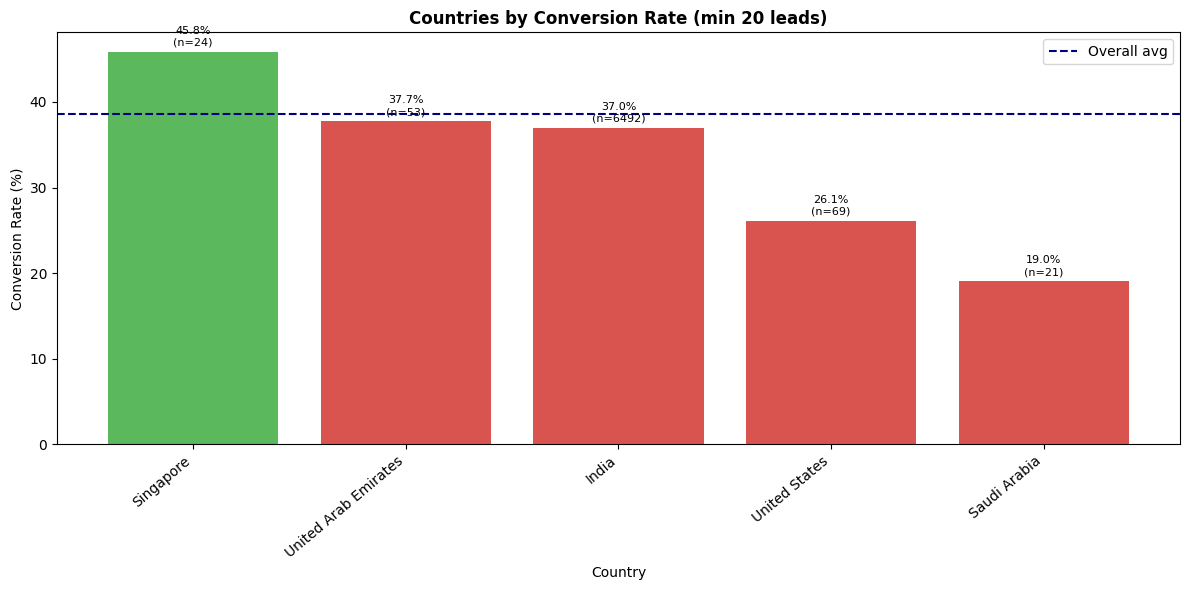

In [85]:
city_stats = (df[df['country'] != 'Missing']
                .groupby('country')['converted']
                .agg(['mean', 'count'])
                .query('count >= 20')
                .rename(columns={'mean': 'conv_rate', 'count': 'volume'})
                .sort_values('conv_rate', ascending=False)
                )
city_stats['conv_rate'] *= 100

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(city_stats.index, city_stats['conv_rate'],
              color=['#5cb85c' if v >= df['converted'].mean()*100 else '#d9534f'
                     for v in city_stats['conv_rate']])
ax.axhline(df['converted'].mean() * 100, color='navy', linestyle='--', label='Overall avg')
ax.set_title('Countries by Conversion Rate (min 20 leads)', fontweight='bold')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Country')
plt.xticks(rotation=40, ha='right')
ax.legend()
for bar, (_, row) in zip(bars, city_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{row['conv_rate']:.1f}%\n(n={int(row['volume'])})",
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


## Insights – Geography

**India is the core market**, accounting for the vast majority of leads (n = 6,492) and converting right at the overall average. **Singapore converts above average (45.8%)** but with a very small sample (n = 24) — treat with caution before scaling investment. **The US (26.1%) and Saudi Arabia (19%)** notably underperform the average, suggesting a messaging or fit mismatch.

> 🎯 **Call to Action:** Keep investing in India — it's the core market. Try adapted messaging in Singapore and UAE before spending more there. Take a closer look at what's not working in the US and Saudi Arabia before putting more budget in.

### 🔹 Lead Profile:

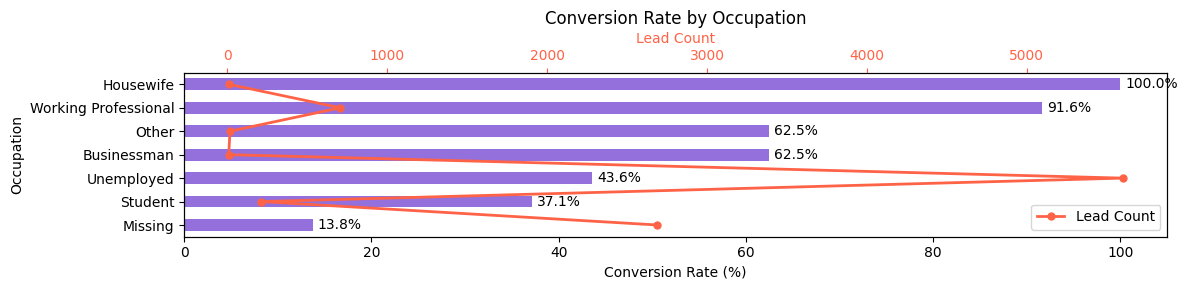


Conversion Rate by Specialization:
                   Specialization  Lead Count  Conversion Rate (%)
            Healthcare Management         159                49.69
Banking, Investment And Insurance         338                49.41
             Marketing Management         838                48.69
            Operations Management         503                47.32
        Human Resource Management         848                45.75
               Finance Management         976                44.67
          Business Administration         403                44.42
          Supply Chain Management         349                43.27
           Rural and Agribusiness          73                42.47
           Hospitality Management         114                42.11
            Media and Advertising         203                41.87
           IT Projects Management         366                38.25
                       E-Business          57                36.84
           International B

In [86]:
fig, ax = plt.subplots(figsize=(12, 3))

occ = df.groupby('what_is_your_current_occupation')['converted'].mean().sort_values(ascending=True) * 100
counts = df.groupby('what_is_your_current_occupation')['converted'].count().reindex(occ.index)

occ.plot(kind='barh', ax=ax, color='mediumpurple')

ax.set_title('Conversion Rate by Occupation')
ax.set_xlabel('Conversion Rate (%)')
ax.set_ylabel('Occupation')

for i, v in enumerate(occ.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')

# Twin axis for lead count line
ax2 = ax.twiny()
ax2.plot(counts.values, range(len(counts)), color='tomato', marker='o', linewidth=2, markersize=5, label='Lead Count')
ax2.set_xlabel('Lead Count', color='tomato')
ax2.tick_params(axis='x', colors='tomato')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

spec = df.groupby('specialization')['converted'].mean().sort_values(ascending=False) * 100
spec_count = df.groupby('specialization')['converted'].count().reindex(spec.index)

spec_df = pd.DataFrame({
    'Specialization': spec.index,
    'Lead Count': spec_count.values,
    'Conversion Rate (%)': spec.values.round(2)
})

print("\nConversion Rate by Specialization:")
print(spec_df.to_string(index=False))

## Insights – Lead Profile by Occupation

**Working Professionals** are the highest-value segment, combining a 91.6% conversion rate with meaningful lead volume. **Students** represent the largest volume (~5,000+ leads) but convert at only 37.1%, creating a significant inefficiency in sales effort. Housewives and Businessmen show high rates but negligible volume, limiting their overall impact.

> 🎯 **Call to Action:** Redirect sales effort away from the broad student segment and toward Working Professionals. When pursuing students, only engage those arriving via high-quality sources such as Reference or Welingak Website.

### 🔹 Cross-Segment: Lead Source × Occupation

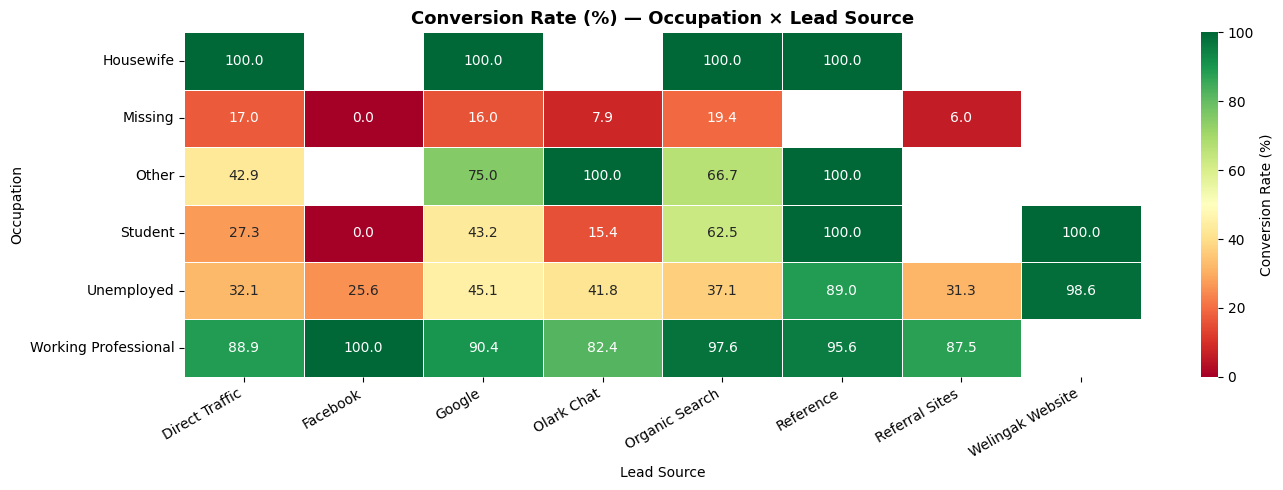

In [87]:
# Filter to top sources and meaningful occupations
top_sources = df['lead_source'].value_counts().head(8).index
top_occs    = df['what_is_your_current_occupation'].value_counts().head(6).index

cross = df[
    df['lead_source'].isin(top_sources) &
    df['what_is_your_current_occupation'].isin(top_occs)
].pivot_table(
    index='what_is_your_current_occupation',
    columns='lead_source',
    values='converted',
    aggfunc='mean'
) * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cross, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, vmin=0, vmax=100, ax=ax,
            cbar_kws={'label': 'Conversion Rate (%)'})
ax.set_title('Conversion Rate (%) — Occupation × Lead Source', fontweight='bold', fontsize=13)
ax.set_xlabel('Lead Source')
ax.set_ylabel('Occupation')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Insights – Cross-Segment (Lead Source × Occupation)

**Working Professionals convert at 82–100% regardless of source** — they are the most reliable segment across every channel. Students are highly source-dependent, converting well from Reference and Welingak Website but near zero via Facebook and Olark Chat. Facebook performs poorly for almost all segments, with Working Professionals as the lone exception (likely a small sample).

> 🎯 **Call to Action:** Concentrate targeting on Working Professionals across all channels. For the student segment, invest only in Reference and high-intent sources. Pause or significantly cut Facebook spend for non-professional audience segments.

### 🔹Do Not Email / Call Impact:

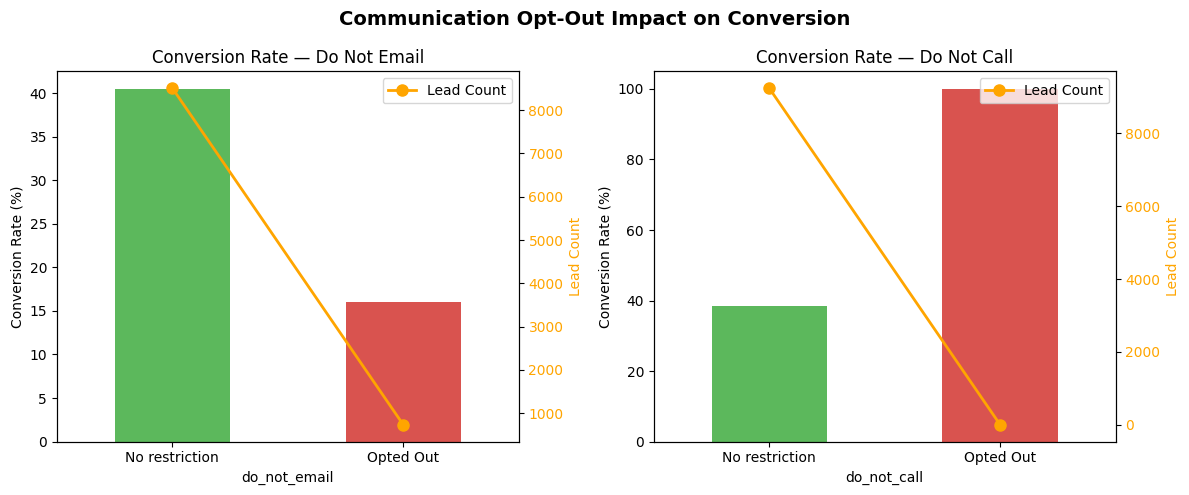

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Communication Opt-Out Impact on Conversion', fontsize=14, fontweight='bold')

for ax, col, title in zip(axes, ['do_not_email', 'do_not_call'], ['Do Not Email', 'Do Not Call']):
    
    conv_rate = df.groupby(col)['converted'].mean().mul(100)
    counts    = df.groupby(col)['converted'].count()
    
    conv_rate.plot(kind='bar', ax=ax, color=['#5cb85c','#d9534f'], zorder=2)
    ax.set_title(f'Conversion Rate — {title}')
    ax.set_xticklabels(['No restriction', 'Opted Out'], rotation=0)
    ax.set_ylabel('Conversion Rate (%)')
    
    # add count line on secondary axis
    ax2 = ax.twinx()
    ax2.plot(range(len(counts)), counts.values, color='orange', marker='o', 
             linewidth=2, markersize=8, label='Lead Count', zorder=3)
    ax2.set_ylabel('Lead Count', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Insights – Communication Opt-Outs

The vast majority of leads (~8,000) have no email restriction, and non-opted-out leads convert at **40% vs. 16%** for those who opted out — a 2.5× gap. The "Do Not Call" opted-out group is negligibly small, making its apparent 100% conversion rate statistically meaningless and not actionable.

> 🎯 **Call to Action:** Use email reachability as a lead quality filter when prioritizing the sales queue. Disregard the "Do Not Call" opt-out conversion figure entirely — the sample size is too small to inform any decision.

### 🔹 Last Activity → Conversion Rate

Which final touchpoint precedes the most conversions?

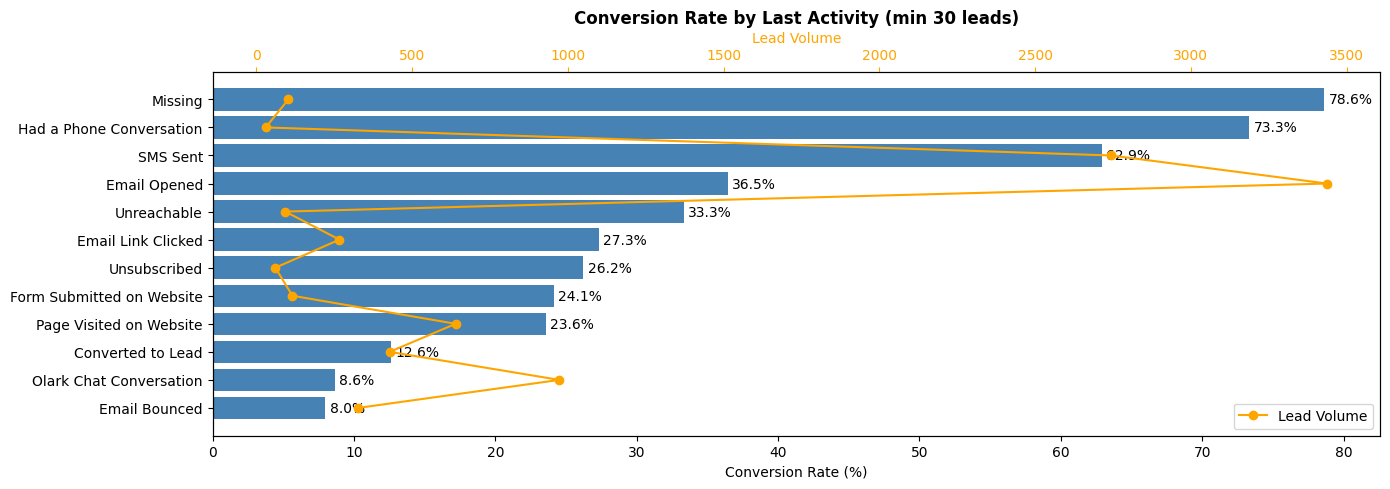

In [89]:
fig, ax = plt.subplots(figsize=(14, 5))

act = (df.groupby('last_activity')['converted']
         .agg(['mean', 'count'])
         .rename(columns={'mean': 'conv_rate', 'count': 'volume'})
         .query('volume >= 30')
         .sort_values('conv_rate', ascending=True))
act['conv_rate'] *= 100

bars = ax.barh(act.index, act['conv_rate'], color='steelblue')
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by Last Activity (min 30 leads)', fontweight='bold')
for bar, val in zip(bars, act['conv_rate']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')

ax2 = ax.twiny()
ax2.plot(act['volume'].values, range(len(act)), 'o-', color='orange', label='Lead Volume')
ax2.set_xlabel('Lead Volume', color='orange')
ax2.tick_params(axis='x', colors='orange')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()


## Insights – Last Activity

The final touchpoint before conversion is a strong predictive signal. Outreach-driven activities — such as **SMS Sent** and **Email Opened** — are associated with higher conversion rates, showing that proactive engagement directly precedes closing. **Olark Chat** interactions indicate leads that are engaged but undecided, making them strong candidates for timely personal follow-up.

> 🎯 **Call to Action:** Build automated follow-up workflows triggered by high-signal last activities (SMS, email opens). Flag all Olark Chat leads for a personal callback within 24 hours.

### 🔹 Tags Analysis

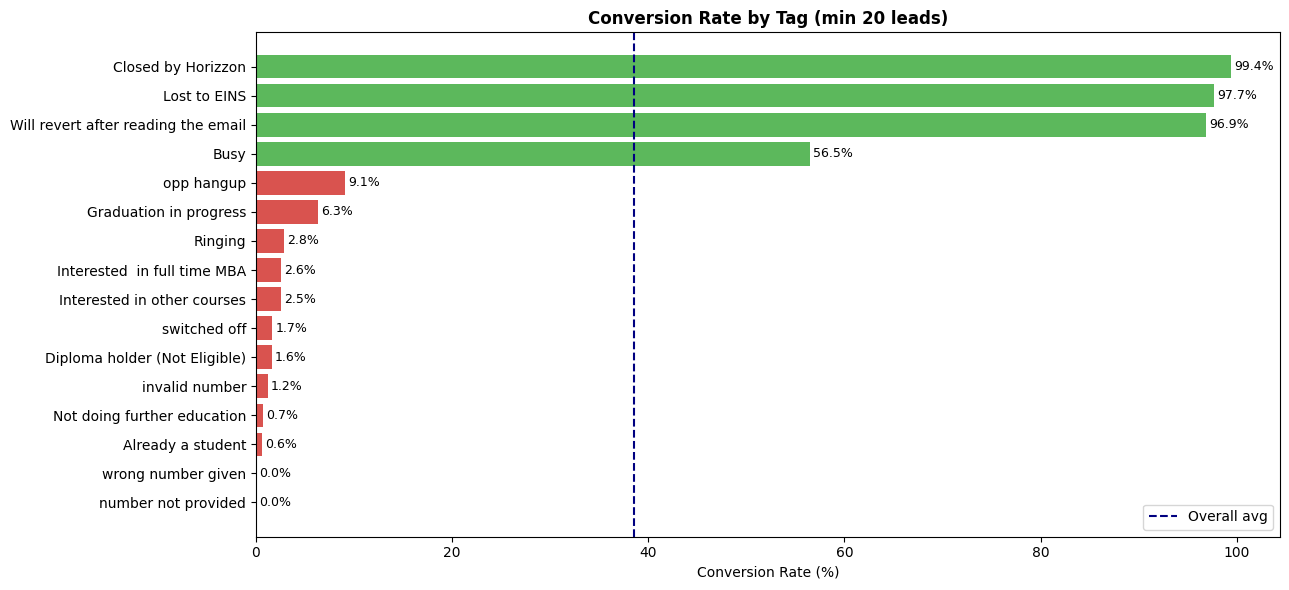

In [90]:
tag_stats = (df[df['tags'] != 'Missing']
               .groupby('tags')['converted']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'conv_rate', 'count': 'volume'})
               .query('volume >= 20')
               .sort_values('conv_rate', ascending=True))
tag_stats['conv_rate'] *= 100

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#5cb85c' if v >= 50 else '#d9534f' for v in tag_stats['conv_rate']]
bars = ax.barh(tag_stats.index, tag_stats['conv_rate'], color=colors)
ax.axvline(df['converted'].mean() * 100, color='navy', linestyle='--', label='Overall avg')
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by Tag (min 20 leads)', fontweight='bold')
ax.legend()
for bar, val in zip(bars, tag_stats['conv_rate']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## Insights – Tags

Tags create a clear two-tier structure. A small set — **"Closed by Horizzon," "Lost to EINS," "Will revert after email"** — converts at 97–99% and represents near-certain closures. All remaining tags (wrong numbers, ineligible leads, unreachable contacts) convert at 0–9% and absorb a disproportionate share of sales effort.

> 🎯 **Call to Action:** Create a sales queue filter that surfaces high-conversion tags as the first priority each day. Flag or deprioritize all leads carrying zero-conversion tags to immediately reclaim sales bandwidth.

### 🔹 Numeric Feature Correlations with Conversion

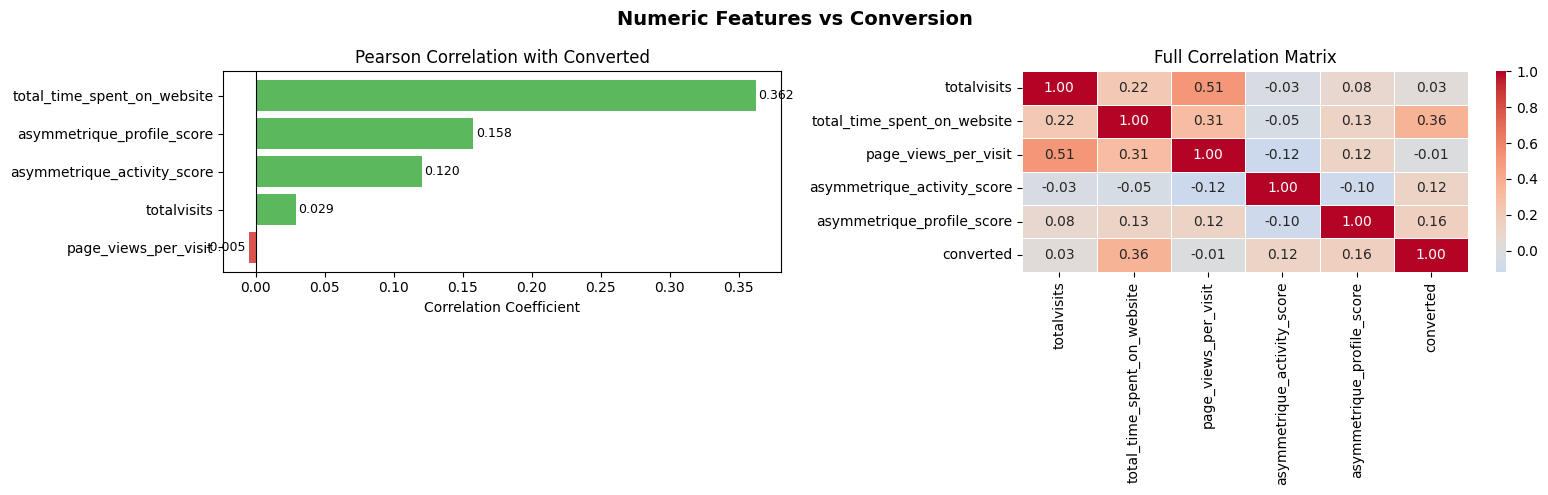

In [91]:
num_cols = ['totalvisits', 'total_time_spent_on_website',
            'page_views_per_visit', 'asymmetrique_activity_score',
            'asymmetrique_profile_score']

corr = df[num_cols + ['converted']].corr()['converted'].drop('converted').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Numeric Features vs Conversion', fontweight='bold', fontsize=14)

colors = ['#d9534f' if v < 0 else '#5cb85c' for v in corr.values]
axes[0].barh(corr.index, corr.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Pearson Correlation with Converted')
axes[0].set_xlabel('Correlation Coefficient')
for i, v in enumerate(corr.values):
    axes[0].text(v + 0.002 if v >= 0 else v - 0.002, i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

sns.heatmap(
    df[num_cols + ['converted']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Full Correlation Matrix')
plt.tight_layout()
plt.show()


## Insights – Numeric Feature Correlations

**Time spent on website (r = 0.36)** is the single strongest numeric predictor of conversion — quality of engagement far outweighs visit frequency. Asymmetrique scores provide a mild but genuine positive signal (0.12–0.16). Total visits (0.03) and page views per visit (−0.005) are effectively noise in isolation and should not be used as standalone scoring signals.

> 🎯 **Call to Action:** Score leads by how long they spend on the website, not by how many times they visit. Flag anyone who browses for 10+ minutes as high priority for outreach.

### 🔹 Asymmetrique Scores — When Present, Are They Predictive?

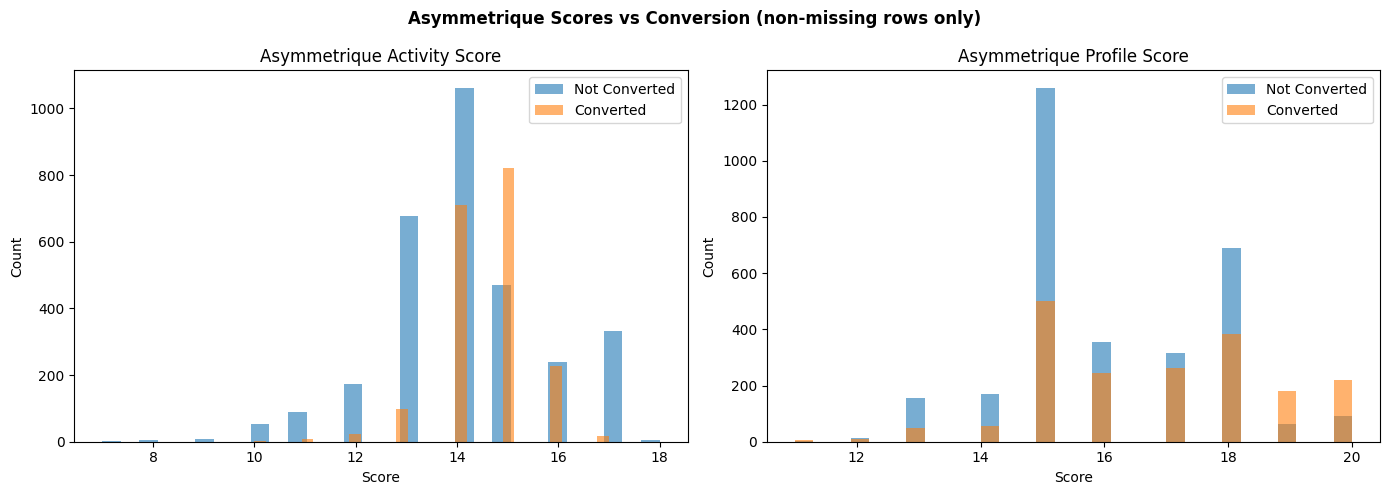

Conversion rate when Asymmetrique score is MISSING vs PRESENT:
asymmetrique_activity_score_was_missing
Score present   38.00
Score missing   39.20
Name: converted, dtype: float64


In [92]:
asym_df = df[df['asymmetrique_activity_score_was_missing'] == 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Asymmetrique Scores vs Conversion (non-missing rows only)', fontweight='bold')

for ax, col, title in zip(axes,
    ['asymmetrique_activity_score', 'asymmetrique_profile_score'],
    ['Activity Score', 'Profile Score']):
    for label, grp in asym_df.groupby('converted'):
        ax.hist(grp[col], bins=30, alpha=0.6,
                label='Converted' if label == 1 else 'Not Converted')
    ax.set_title(f'Asymmetrique {title}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

# Missingness signal
print('Conversion rate when Asymmetrique score is MISSING vs PRESENT:')
print(df.groupby('asymmetrique_activity_score_was_missing')['converted']
        .mean().mul(100).rename({0: 'Score present', 1: 'Score missing'}).round(1))


## Insights – Asymmetrique Scores

Both Activity Score and Profile Score show a **weak but genuine positive correlation** with conversion. Profile Score provides slightly cleaner group separation — converted leads cluster at scores 15–16 while non-converted leads are more prevalent at 12–13. Note that these scores are only populated for ~55% of leads, limiting their standalone utility.

> 🎯 **Call to Action:** Combine Asymmetrique Profile Score (≥ 15) with time-on-site and tag data to build a lightweight, high-precision lead scoring rule. Use the absence of a score as a signal to prompt CRM enrichment before outreach.